In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [38]:
# Dataset loading
name = '3_xhl_imputMF_future_filled_month_mb_ep'
csv_path = f"/content/drive/MyDrive/river_runoff_obs/{name}.csv"

In [39]:
try:
  dataFrame_full = pd.read_csv(csv_path, usecols=usecols)
except:
  from google.colab import drive
  drive.mount('/content/drive')

In [40]:
usecols = ['time', 'pre', 'tm', 'mb', 'dis','ep']
df_full = pd.read_csv(csv_path, usecols=usecols)
df = df_full.dropna()
df_future = df_full[df_full.dis.isnull()]

In [41]:
df_future

,time,pre,tm,mb,dis,ep
223,2019/1/31,2.754059,-11.649656,3.382182,NaN,9.050104
224,2019/2/28,3.132738,-6.361061,1.593807,NaN,11.714730
225,2019/3/31,3.612614,3.231265,0.910453,NaN,33.229638
226,2019/4/30,20.112581,11.833850,1.066161,NaN,117.651693
227,2019/5/31,21.457021,12.237765,1.670937,NaN,205.230872
...,...,...,...,...,...,...
926,2077/8/31,44.759238,17.508011,6.711403,NaN,NaN
927,2077/9/30,48.163448,13.093739,-12.722413,NaN,NaN
928,2077/10/31,14.131040,6.712247,-58.819638,NaN,NaN
929,2077/11/30,2.043830,-0.984374,-52.739687,NaN,NaN


In [42]:
epochs=256
batch_size=24
file_name = f'{name}_{epochs}_{batch_size}'

In [43]:
# Prepare features (X) and targets (y)
X = df[['pre', 'tm', 'mb']].values  # Inputs: precipitation, temperature, mass balance
y = df[['dis', 'ep']].values         # Outputs: runoff (dis) and evaporation (ep)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2)  # Output layer with two units for runoff and evaporation
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2)

# Make predictions
predictions = model.predict(X_test)
predictions_rescaled = scaler_y.inverse_transform(predictions)

# Convert predictions to DataFrame for runoff and evaporation
pred_df = pd.DataFrame(predictions_rescaled, columns=['predicted_runoff', 'predicted_ep'])
print(pred_df.head())

Epoch 1/256


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.9644 - val_loss: 0.7553
Epoch 2/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6948 - val_loss: 0.5715
Epoch 3/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5834 - val_loss: 0.4403
Epoch 4/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3281 - val_loss: 0.3572
Epoch 5/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3527 - val_loss: 0.2954
Epoch 6/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2322 - val_loss: 0.2752
Epoch 7/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2353 - val_loss: 0.2598
Epoch 8/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2728 - val_loss: 0.2371
Epoch 9/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2357 - val_loss: 0.2221
Epoch 10/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1479 - val_loss: 0.2115
Epoch 11/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1729 - val_loss: 0.1976
Epoch 12/256
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1125 - val_loss: 0.1855
Epoch 13

In [44]:
from sklearn.metrics import mean_squared_error

# Define the NSE function
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))

# Calculate predictions and rescale
predictions = model.predict(X_test)
predictions_rescaled = scaler_y.inverse_transform(predictions)

# Separate the predicted and actual values for runoff and evaporation
y_test_rescaled = scaler_y.inverse_transform(y_test)
runoff_observed = y_test_rescaled[:, 0]
evaporation_observed = y_test_rescaled[:, 1]
runoff_predicted = predictions_rescaled[:, 0]
evaporation_predicted = predictions_rescaled[:, 1]

# Calculate NSE for runoff and evaporation
nse_runoff = nse(runoff_observed, runoff_predicted)
nse_evaporation = nse(evaporation_observed, evaporation_predicted)

# Print NSE values
print(f"NSE for Runoff (dis): {nse_runoff:.4f}")
print(f"NSE for Evaporation (ep): {nse_evaporation:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
NSE for Runoff (dis): 0.8519
NSE for Evaporation (ep): 0.9460


In [45]:
# Assuming future_df is loaded and has the same columns as df
# Extract features from future_df
X_future = df_future[['pre', 'tm', 'mb']].values  # Only the input features

# Standardize features based on the training data scaler
X_future_scaled = scaler_X.transform(X_future)

# Predict future runoff and evaporation
future_predictions_scaled = model.predict(X_future_scaled)

# Rescale predictions to original scale
future_predictions = scaler_y.inverse_transform(future_predictions_scaled)

# Convert predictions to DataFrame for readability
df_future[['Projected_Runoff', 'Projected_Evaporation']] = future_predictions
print(df_future[['Projected_Runoff', 'Projected_Evaporation']].head())


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
     Projected_Runoff  Projected_Evaporation
223       1099.180054              11.065730
224        751.102844              15.258479
225        947.837708              57.401333
226       1956.855103             212.721420
227       2173.063232             263.892334


<ipython-input-45-ecb23519956c>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_future[['Projected_Runoff', 'Projected_Evaporation']] = future_predictions
<ipython-input-45-ecb23519956c>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_future[['Projected_Runoff', 'Projected_Evaporation']] = future_predictions


In [46]:
df

,time,pre,tm,mb,dis,ep
0,2000/6/30,32.134505,16.288230,3.828244,8523.9,392.170402
1,2000/7/31,34.919888,18.124691,6.513560,19310.0,497.053757
2,2000/8/31,19.852628,16.877223,8.565922,16141.0,690.012094
3,2000/9/30,26.971720,12.736307,-2.165933,5873.0,182.160480
4,2000/10/31,5.757602,4.884766,-31.076998,1923.8,48.999704
...,...,...,...,...,...,...
218,2018/8/31,49.025188,16.830065,9.514803,13737.0,480.317800
219,2018/9/30,16.879361,12.613500,-5.477070,4370.2,208.091125
220,2018/10/31,4.975861,5.765065,-39.423097,2155.7,62.319923
221,2018/11/30,5.994139,-2.223100,-31.457713,1394.5,28.852058


In [47]:
# Convert the 'time' column to datetime format if needed
df['time'] = pd.to_datetime(df['time'])
df_future['time'] = pd.to_datetime(df_future['time'])
# Ensure 'time' is set as the index for both DataFrames if not already
df.set_index('time', inplace=True)
df_future.set_index('time', inplace=True)

<ipython-input-47-1a68032cf54d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time'] = pd.to_datetime(df['time'])
<ipython-input-47-1a68032cf54d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_future['time'] = pd.to_datetime(df_future['time'])


In [48]:
# Concatenate along rows
combined_df = pd.concat([df, df_future], axis=0)

# Sort by time if needed
combined_df.sort_index(inplace=True)

# Display the combined DataFrame
print(combined_df.head())
print(combined_df.tail())


                  pre         tm         mb      dis          ep  \
time                                                               
2000-06-30  32.134505  16.288230   3.828244   8523.9  392.170402   
2000-07-31  34.919888  18.124691   6.513560  19310.0  497.053757   
2000-08-31  19.852628  16.877223   8.565922  16141.0  690.012094   
2000-09-30  26.971720  12.736307  -2.165933   5873.0  182.160480   
2000-10-31   5.757602   4.884766 -31.076998   1923.8   48.999704   

            Projected_Runoff  Projected_Evaporation  
time                                                 
2000-06-30               NaN                    NaN  
2000-07-31               NaN                    NaN  
2000-08-31               NaN                    NaN  
2000-09-30               NaN                    NaN  
2000-10-31               NaN                    NaN  
                  pre         tm         mb  dis  ep  Projected_Runoff  \
time                                                                   

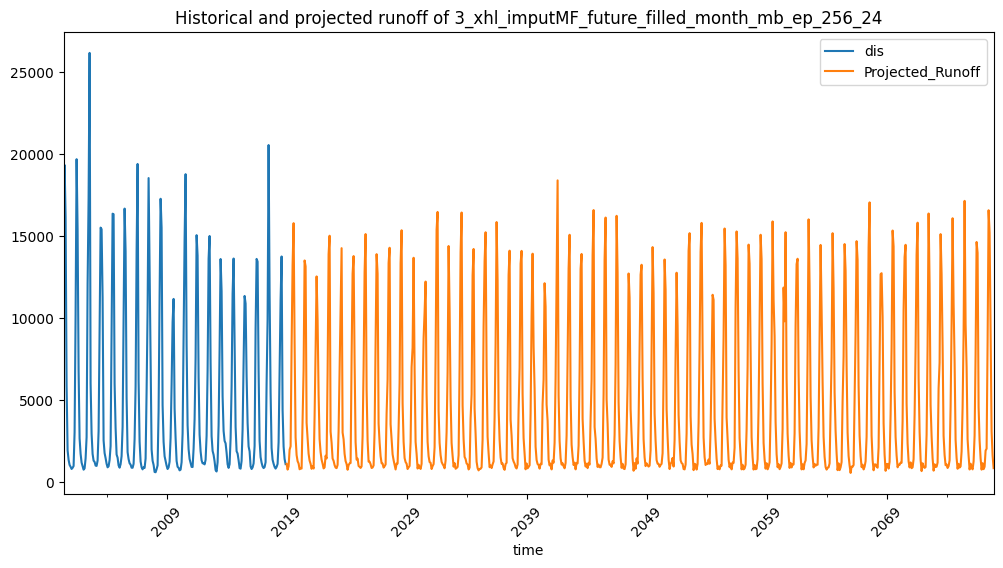

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Plot with a larger figure size
ax = combined_df[['dis', 'Projected_Runoff']].plot(figsize=(12, 6))
# Optional: Rotate x-tick labels for better readability
plt.xticks(rotation=45)
plt.title(f"Historical and projected runoff of {file_name}")
# Show the plot
plt.show()

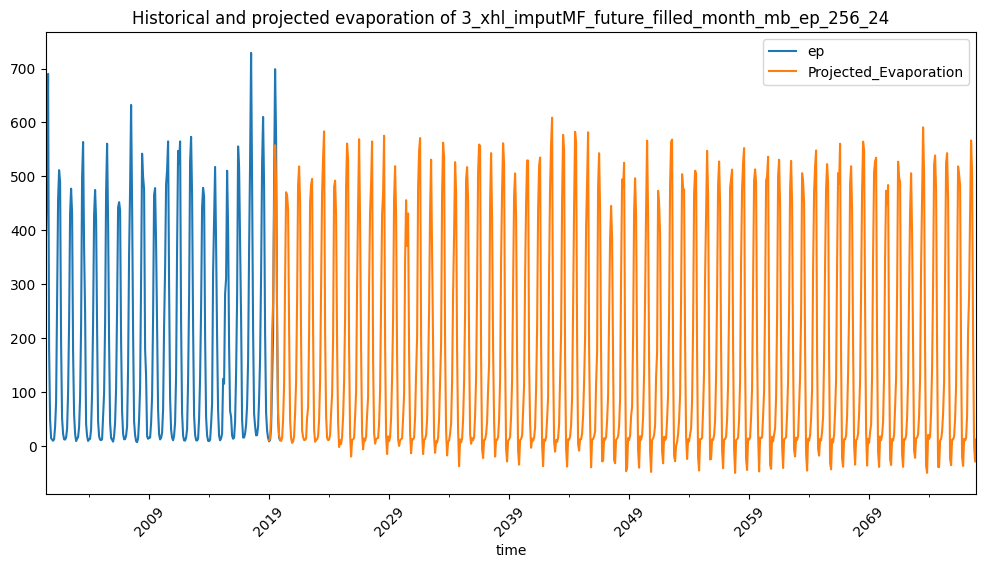

In [50]:
# Plot with a larger figure size
ax = combined_df[['ep', 'Projected_Evaporation']].plot(figsize=(12, 6))
# Optional: Rotate x-tick labels for better readability
plt.xticks(rotation=45)
plt.title(f"Historical and projected evaporation of {file_name}")
# Show the plot
plt.show()

In [51]:
combined_df.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{file_name}_project.csv")

In [53]:
# Resample the DataFrame to annual frequency
annual_df = combined_df.resample('Y').agg({
    'pre': 'sum',
    'tm': 'mean',
    'mb': 'sum',
    'dis': 'sum',
    'ep': 'sum',
    'Projected_Runoff': 'sum',
    'Projected_Evaporation': 'sum'
})

# Optionally, reset the index if you don't want 'time' as index anymore
annual_df.reset_index(inplace=True)

# Display the result
print(annual_df.head())

        time         pre        tm         mb      dis           ep  \
0 2000-12-31  127.077246  8.297006 -28.013096  54149.2  1837.330240   
1 2001-12-31  217.655580  5.694010 -23.505854  64171.6  2153.939481   
2 2002-12-31  220.363804  5.714420 -24.235175  74108.5  1995.488301   
3 2003-12-31  234.435638  5.231777 -34.362257  65117.0  2126.600207   
4 2004-12-31  181.240881  6.105577 -21.564407  60692.1  2006.147793   

   Projected_Runoff  Projected_Evaporation  
0               0.0                    0.0  
1               0.0                    0.0  
2               0.0                    0.0  
3               0.0                    0.0  
4               0.0                    0.0  


<ipython-input-53-4ab3b750624d>:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_df = combined_df.resample('Y').agg({


<Axes: >

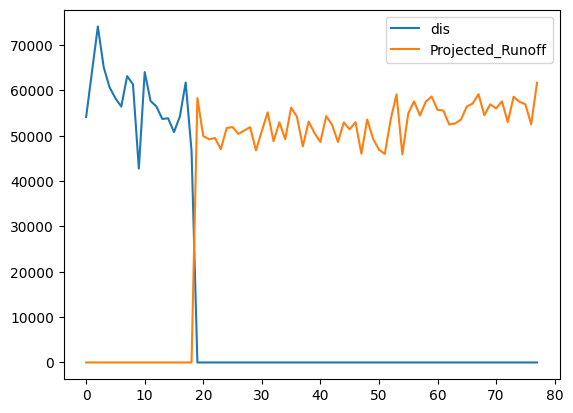

In [55]:
annual_df[['dis', 'Projected_Runoff']].plot()